# 🎵 Spotify Recommender System
### Step-by-step notebook: Data Collection → EDA → Model → Recommendations

## 📦 Cell 1 — Install & Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Cell 2 — Load the Kaggle Dataset

In [3]:
df = pd.read_csv("dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.tail()


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(5)

Shape: (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 🧹 Cell 3 — Data Cleaning & Preprocessing

In [17]:
# Drop unnamed index column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

In [7]:
print(f'Columns: {df.columns.tolist()}')
df.head(5)

Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [18]:
# Check null values
print('Null values:')
print(df.isnull().sum())

Null values:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [19]:
# Drop rows with nulls
df = df.dropna()

In [20]:
print(df.isnull().sum())

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [21]:
# Remove duplicate tracks
before = len(df)
df = df.drop_duplicates(subset='track_id')
print(f'\nRemoved {before - len(df)} duplicates. Remaining: {len(df)} tracks')


Removed 24259 duplicates. Remaining: 89740 tracks


## 📊 Cell 4 — Exploratory Data Analysis (EDA)

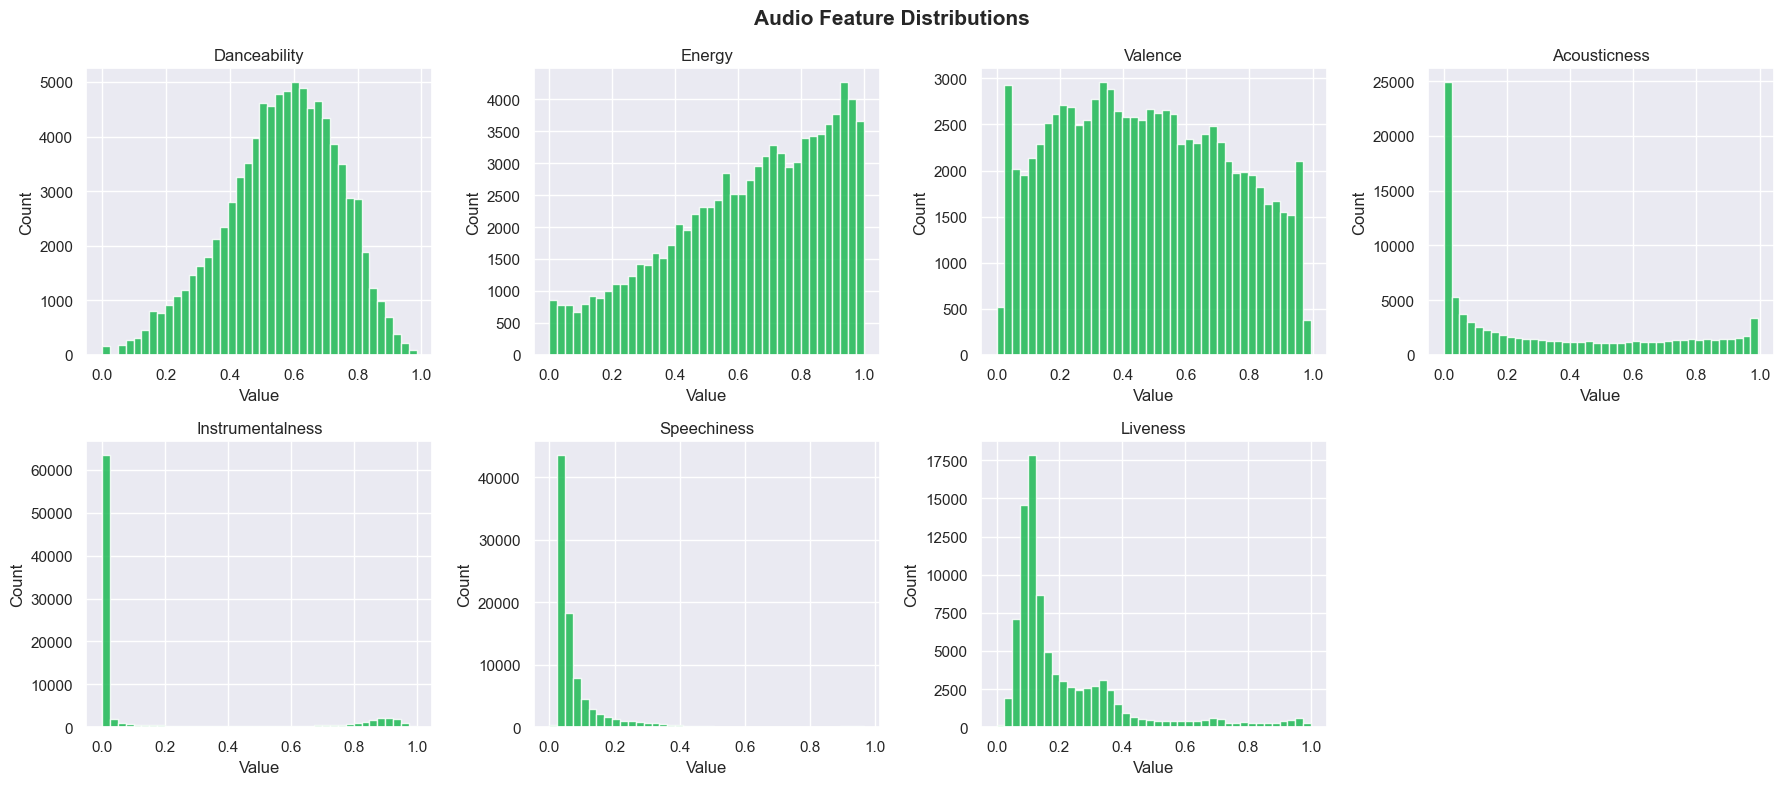

In [25]:
# Audio feature distributions
audio_features = ['danceability', 'energy', 'valence', 'acousticness',
                  'instrumentalness', 'speechiness', 'liveness']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].hist(df[feature], bins=40, color='#1DB954', edgecolor='white', alpha=0.85)
    axes[i].set_title(feature.capitalize(), fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].axis('off')  # hide last empty subplot
plt.suptitle('Audio Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

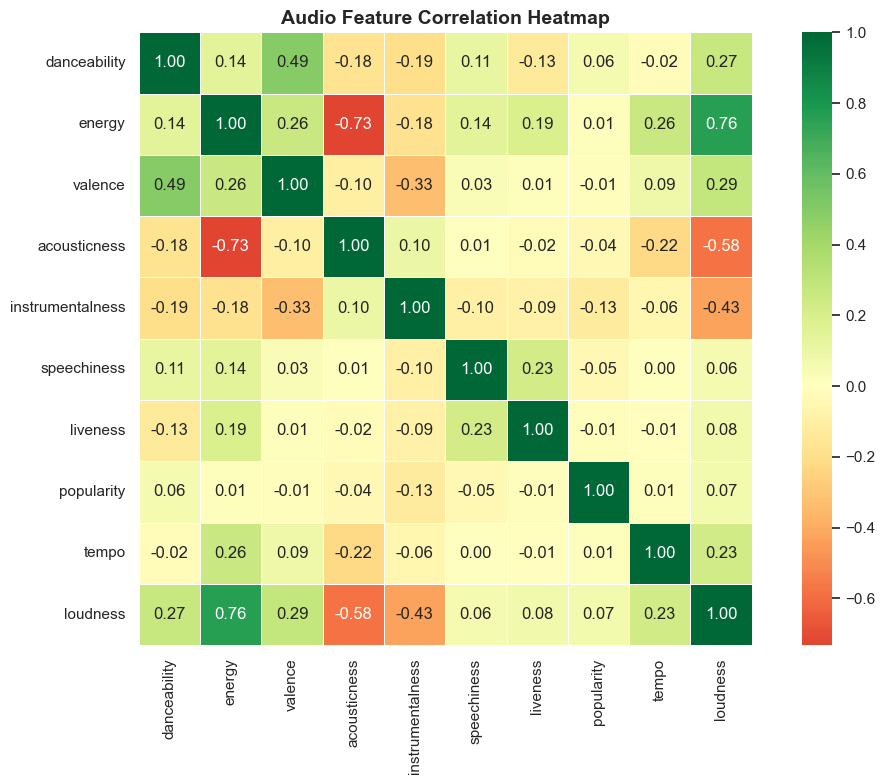

In [26]:
# Correlation heatmap
corr_features = audio_features + ['popularity', 'tempo', 'loudness']
corr = df[corr_features].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True)
plt.title('Audio Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

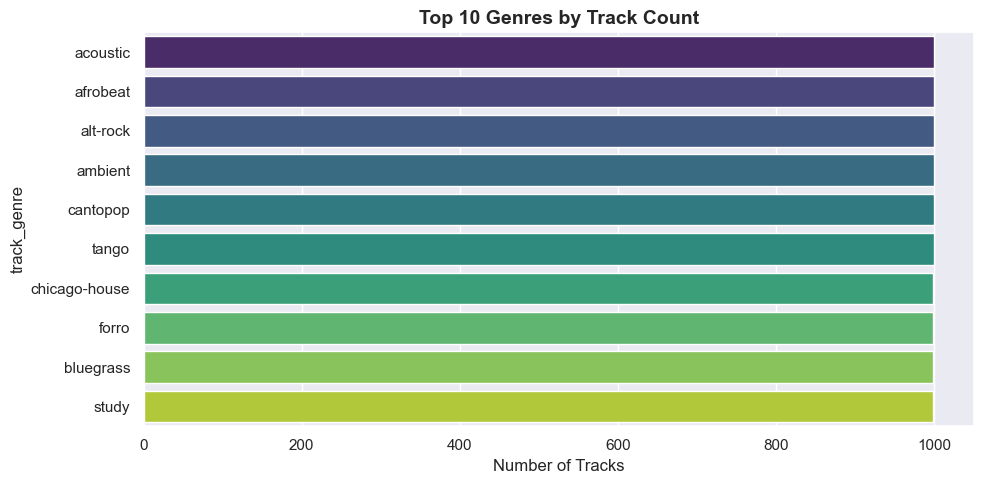

In [27]:
# Top 10 genres by track count
top_genres = df['track_genre'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Genres by Track Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tracks')
plt.tight_layout()
plt.show()

## ⚙️ Cell 5 — Feature Engineering & Normalization

In [28]:
# Select audio features for the model
FEATURES = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

In [29]:
# Normalize features to 0-1 range
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[FEATURES] = scaler.fit_transform(df[FEATURES])

print('✅ Features normalized!')
df_scaled[FEATURES].describe().round(3)

✅ Features normalized!


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,89740.000,89740.000,89740.000,89740.000,89740.000,89740.000,89740.000,89740.000,89740.000
mean,0.571,0.634,0.759,0.091,0.330,0.173,0.217,0.472,0.502
std,0.179,0.257,0.097,0.117,0.340,0.324,0.195,0.264,0.124
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.457,0.457,0.725,0.037,0.017,0.000,0.098,0.250,0.408
50%,0.585,0.676,0.783,0.051,0.189,0.000,0.132,0.459,0.501
75%,0.703,0.853,0.822,0.089,0.628,0.098,0.279,0.685,0.576
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 🤖 Cell 6 — Content-Based Recommender (Cosine Similarity)

In [30]:
# Build feature matrix
feature_matrix = df_scaled[FEATURES].values

# Reset index for easy lookup
df_scaled = df_scaled.reset_index(drop=True)

def recommend_songs(song_name, n=10):
    """
    Recommend N songs similar to the given song name
    based on audio feature cosine similarity.
    """
    # Find the song in the dataset
    matches = df_scaled[df_scaled['track_name'].str.lower() == song_name.lower()]
    
    if matches.empty:
        # Try partial match
        matches = df_scaled[df_scaled['track_name'].str.lower().str.contains(song_name.lower())]
    
    if matches.empty:
        print(f"❌ Song '{song_name}' not found in dataset.")
        return None
    
    # Use first match
    idx = matches.index[0]
    seed_song = df_scaled.iloc[idx]
    print(f"🎵 Seed song: '{seed_song['track_name']}' by {seed_song['artists']}")
    print(f"   Genre: {seed_song['track_genre']} | Popularity: {seed_song['popularity']}\n")
    
    # Compute cosine similarity between seed and all songs
    seed_vector = feature_matrix[idx].reshape(1, -1)
    similarities = cosine_similarity(seed_vector, feature_matrix)[0]
    
    # Get top N most similar (excluding seed song itself)
    similar_indices = similarities.argsort()[::-1][1:n+1]
    
    recommendations = df_scaled.iloc[similar_indices][[
        'track_name', 'artists', 'track_genre', 'popularity', 'valence', 'energy', 'danceability'
    ]].copy()
    recommendations['similarity_score'] = similarities[similar_indices].round(4)
    recommendations = recommendations.reset_index(drop=True)
    recommendations.index += 1  # start ranking from 1
    
    return recommendations

print('✅ Recommender function ready!')

✅ Recommender function ready!


## 🎯 Cell 7 — Get Recommendations!

In [31]:
# Try it with any song in the dataset!
results = recommend_songs('Shape of You', n=10)

if results is not None:
    print('🎧 Top 10 Recommendations:')
    display(results)

🎵 Seed song: 'Shape Of You' by Andrew Foy
   Genre: guitar | Popularity: 24

🎧 Top 10 Recommendations:


,track_name,artists,track_genre,popularity,valence,energy,danceability,similarity_score
1,Les Indes Galantes - Air pour les esclaves afr...,Jean-Philippe Rameau;Jordi Savall;Le Concert D...,opera,21,0.738693,0.277,0.582741,0.9988
2,Sink Lateral,Ilkae,idm,12,0.923618,0.401,0.688325,0.9966
3,Reno Ride,Clarence White,bluegrass,24,0.929648,0.317,0.509645,0.9965
4,Inner Courage,Mr. Käfer;Eu93ne,jazz,58,0.968844,0.321,0.726904,0.9963
5,Keali'i's Mele,Danny Carvalho,guitar,20,0.792965,0.339,0.498477,0.9960
6,Dill Pickles Rag,Jo Ann Castle,honky-tonk,16,0.978894,0.321,0.729949,0.9958
7,Yes Sir That's My Baby,Mrs Mills,honky-tonk,17,0.951759,0.393,0.777665,0.9956
8,Darktown Strutters Ball,Crazy Otto,honky-tonk,11,0.895477,0.355,0.662944,0.9953
9,Milonga Brava,Francisco Canaro;Roberto Maida,tango,16,0.833166,0.399,0.760406,0.9953
10,Minha Saudade,João Gilberto,guitar,23,0.818090,0.435,0.587817,0.9951


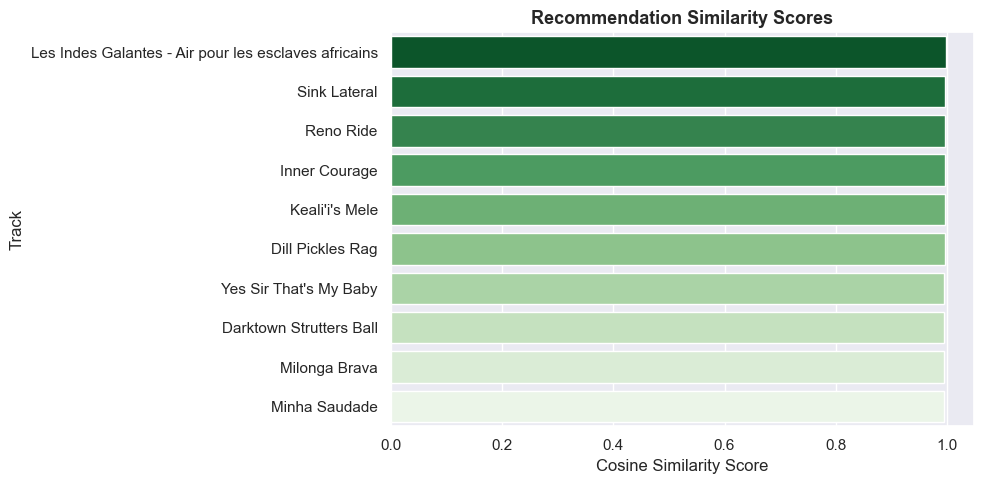

In [32]:
# Visualize recommendation scores
if results is not None:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=results, x='similarity_score', y='track_name', palette='Greens_r')
    plt.title('Recommendation Similarity Scores', fontsize=13, fontweight='bold')
    plt.xlabel('Cosine Similarity Score')
    plt.ylabel('Track')
    plt.tight_layout()
    plt.show()

## 💾 Cell 8 — Save Cleaned Dataset

In [37]:
df.to_csv('cleaned_data.csv', index=False)
print(f'✅ Saved {len(df_scaled)} tracks to data/tracks_clean.csv')
print('\nNext step: Add Collaborative Filtering or deploy with Streamlit!')



✅ Saved 89740 tracks to data/tracks_clean.csv

Next step: Add Collaborative Filtering or deploy with Streamlit!
